In [110]:
import numpy as np
import matplotlib.pyplot as plt
from nav_msgs.msg import OccupancyGrid
from geometry_msgs.msg import Pose
import random
import math
from scipy.spatial import cKDTree
from scipy.ndimage import distance_transform_edt
from skimage.draw import line

In [111]:
# Create the grid
grid = OccupancyGrid()
grid.info.width = 100
grid.info.height = 100
grid.info.resolution = 0.1
grid.info.origin = Pose()

data_np = np.zeros((grid.info.height, grid.info.width), dtype=np.int8)

data_np[75:80, 15:55] = 100
data_np[15:70, 15:20] = 100
data_np[15:20, 15:65] = 100
data_np[25:55, 75:80] = 100
data_np[60:65, 35:80] = 100
data_np[30:55, 35:40] = 100


# Flatten to 1D list for OccupancyGrid
grid.data = data_np.flatten().tolist()

In [112]:
import numpy as np
import matplotlib.pyplot as plt
from nav_msgs.msg import OccupancyGrid
from geometry_msgs.msg import Pose
import random
import math
from scipy.spatial import cKDTree
from scipy.ndimage import distance_transform_edt
from skimage.draw import line

class Node:
    def __init__(self, x, y):
        self.x = x
        self.y = y
        self.parent = None
        self.children = []
        self.cost = 0.0
        self.path_length = 0.0
        self.obstacle_cost = 0.0

    def add_child(self, x, y):
        child_node = Node(x, y)
        child_node.parent = self
        self.children.append(child_node)
        return child_node
    
    def __repr__(self):
        parent_str = f"({self.parent.x:.2f}, {self.parent.y:.2f})" if self.parent else "None"
        return f"Node(x={self.x:.2f}, y={self.y:.2f}, parent={parent_str}, children={len(self.children)})"
        

class RRT():
    def __init__(self, node, occupancy_grid, num_iterations, goal):
        self.root_node = node
        self.nodes = [self.root_node]
        self.og = occupancy_grid
        self.obstacle_weight = 0.05

        self.num_iterations = num_iterations
        self.tree_size = 1
        self.step_size = 0.1
        self.sample_goal_bias = 0.05
        self.goal = goal
        self.r_goal = 0.35
        self.best_cost = float('inf')
        self.best_node = None
        self.best_path_length = float('inf')

        grid = self.convert2grid(self.og)
        obstacle_mask = (grid != 100).astype(np.uint8)
        dist_cells = distance_transform_edt(obstacle_mask)
        self.distance_map = dist_cells * self.og.info.resolution

        self.node_coords = [(node.x, node.y)]
        self.kd_tree = cKDTree(self.node_coords)

        self.gamma_rrt = 2.0
        self.d = 2

        self.sols_found = 0

    def add_node(self, new_node):
        self.nodes.append(new_node)
        self.node_coords.append((new_node.x, new_node.y))
        self.tree_size += 1

        if self.tree_size % 50 == 0:
            self.kd_tree = cKDTree(self.node_coords)

    # primitive procedures from https://arxiv.org/pdf/1105.1186

    def sample_free(self):
        if random.random() < self.sample_goal_bias:
            return self.goal

        x = self.og.info.origin.position.x + random.uniform(0, self.og.info.width * self.og.info.resolution)
        y = self.og.info.origin.position.y + random.uniform(0, self.og.info.height * self.og.info.resolution)
        x_rand = (x, y)
        return x_rand
    
    def informed_sample(self, x_start, x_goal, c_best):
        # informed RRT* från den här: https://arxiv.org/pdf/1404.2334
        x0, y0 = x_start
        x1, y1 = x_goal

        # den teoretiskt lägsta kostnaden man kan få vore att gå fågelvägen mellan start och mål
        c_min = math.hypot(x1 - x0, y1 - y0)

        # sampla från en ellips som täcker start och mål efter att man hittat en lösning
        # ... best_cost är infinite när man startar koden
        if not math.isfinite(c_best) or c_best <= c_min:
            return self.sample_free()
        
        # ellipsen har sin mittpunkt exakt mellan starten och målet
        ellipse_center_x = 0.5 * (x0 + x1)
        ellipse_center_y = 0.5 * (y0 + y1)

        # behöver theta för att kunna rotera ellipsen
        theta = math.atan2(y1 - y0, x1 - x0)

        # r1 är det långt strecket i ellipsen, som går i en oroterad ellips går längs x-axeln
        r1 = c_best / 2.0 # formeln för denna är skriven i artikeln, Algorithm 2: rad 5
        # r2 är det kort strecket i ellipsen (längs y-axeln)
        r2 = math.sqrt(c_best**2 - c_min**2) / 2.0 # formeln för denna är skriven i artikeln, Algorithm 2: rad 6

        # Algorithm 2: rad 8, SampleUnitBall
        u = random.random()
        v = random.random()
        r = math.sqrt(u) # Man tar roten ur här för uniform distribution, annars klumpar sig punkterna runt origo
        angle = 2.0 * math.pi * v
        x_ball = r * math.cos(angle)
        y_ball = r * math.sin(angle)

        # Algorithm 2: rad 9
        x_ell = r1 * x_ball # man sträcker ut bollen i x-led
        y_ell = r2 * y_ball # man sträcker ut bollen i y-led

        # man applicerar rotation, hade kunnat använda rotationsmatris
        x_rot = x_ell * math.cos(theta) - y_ell * math.sin(theta)
        y_rot = x_ell * math.sin(theta) + y_ell * math.cos(theta)

        # bollen vi samplade var runt origo, man behöver translatera den baserat på mitten av ellipsen
        x_rand = x_rot + ellipse_center_x
        y_rand = y_rot + ellipse_center_y

        return (x_rand, y_rand)
    
    def nearest(self, x_rand):
        # att använda kd-tree ska ha bättre tidskomplexitet för både near och nearest än att loop igenom samtliga noder
        distance, idx = self.kd_tree.query(x_rand)
        return self.nodes[idx]
    
    def near(self, x_new, radius):
        indices = self.kd_tree.query_ball_point(x_new, radius)
        nodes = []
        for i in indices:
            nodes.append(self.nodes[i])
        return nodes
    
    def steer(self, x_nearest, x_rand):
        # kollar vilken riktning vi samplat åt och väljer en punkt, step_size långt ifrån ursprungspunkten
        theta = math.atan2(x_rand[1] - x_nearest.y, x_rand[0] - x_nearest.x)
        x_new = x_nearest.x + self.step_size * math.cos(theta)
        y_new = x_nearest.y + self.step_size * math.sin(theta)
        return (x_new, y_new)
    
    def collision_free(self, x_nearest, x_new):
        x0, y0 = self.world_to_grid(x_nearest)
        x1, y1 = self.world_to_grid(x_new)

        # line-funktionen från skimage ritar en linje mellan 2 celler och returnerar alla celler den passerar igenom
        # finns också nånting som heter Bresenham's algoritm men den var gode komplicerad
        row, col = line(y0, x0, y1, x1)

        # fick index out of bound vi något tillfälle, borde inte ha fått det dock
        for gy, gx in zip(row, col):
            if gx < 0 or gy < 0 or gx >= self.og.info.width or gy >= self.og.info.height:
                return False

            index = gy * self.og.info.width + gx
            value = self.og.data[index]

            # en cell är occupied om det har värdet 100
            if value == 100 or value == -1:
                return False

        return True
    
    # fågelvägen mellan 2 punkter
    def line_cost(self, p1, p2):
        return math.hypot(p1[0] - p2[0], p1[1] - p2[1])
    
    # använd en målzon för annars måste man sampla exakta målkoordinaterna för att hitta lösning
    def in_goal_region(self, x):
        return math.hypot(x[0] - self.goal[0], x[1] - self.goal[1]) < self.r_goal # den behövde sättas större in inflate för annars kan man inte nå många frontiers
            
    # helper

    def world_to_grid(self, point):
        x, y = point
        gx = int((x - self.og.info.origin.position.x) / self.og.info.resolution)
        gy = int((y - self.og.info.origin.position.y) / self.og.info.resolution)
        return gx, gy
    
    # man beräknar radien dynamiskt enligt https://arxiv.org/pdf/1105.1186
    def get_radius(self):
        d = self.d
        gamma_rrt = self.gamma_rrt
        n = max(self.tree_size, 2)

        radius = min(gamma_rrt * (math.log(n) / n) ** (1 / d), self.step_size)
        return radius
    
    def plot_tree(self):
        xs = []
        ys = []
        gx = self.goal[0]
        gy = self.goal[1]

        for node in self.nodes:
            xs.append(node.x)
            ys.append(node.y)
            
            for child in node.children:
                plt.plot([node.x, child.x], [node.y, child.y], 'b-', linewidth=0.8)


        plt.scatter(xs, ys, s=10, c='red')
        plt.scatter(gx, gy, s=20, c='green', marker='X')


        if self.best_node:
             path, _ = self.extract_best_path()
             px, py = zip(*path)
             plt.plot(px, py, 'y-', linewidth=1.5, label="best path")

    # vi gör run_RRT för att bygga upp trädet men behöver en funktion för att plocka ut den bästa vägen
    def extract_best_path(self):
        if self.best_node is None:
            return [], self.best_cost
        
        path = []
        current = self.best_node
        while current is not None:
            path.append((current.x, current.y))
            current = current.parent

        path.reverse() # flippar ordningen så att listan går från start -> mål istället
        return path, self.best_cost
    
    def get_obstacle_dist(self, x, y):
        gx, gy = self.world_to_grid((x, y))
        return self.distance_map[gy, gx]
    
    def convert2grid(self, occupancy_grid_msg):
        width = occupancy_grid_msg.info.width
        height = occupancy_grid_msg.info.height

        map_grid = np.array(occupancy_grid_msg.data).reshape((height, width))

        return map_grid
    
    # the main algorithm

    def run_RRT(self):
        # vi kör en bestämd mängd iterationer och sparar den bästa lösningen
        i = 0
        while i < self.num_iterations:
            i += 1
            # man samplar över hela kartan tills man hittar första lösningen och därefter samplar i en ellips (informed RRT*)
            x_rand = self.informed_sample((self.root_node.x, self.root_node.y), (self.goal[0], self.goal[1]), self.best_path_length)
            x_nearest = self.nearest(x_rand)
            x_new = self.steer(x_nearest, x_rand)

            # -- detta block handlar i stort sett bara om att koppla den nya noden till den parent som ger lägst cost (bäst väg)
            if self.collision_free((x_nearest.x, x_nearest.y), x_new):
                x_near = self.near(x_new, self.get_radius())
                x_new_node = Node(x_new[0], x_new[1])
                
                segment_length = self.line_cost(x_new, (x_nearest.x, x_nearest.y))
                x_new_node.path_length = x_nearest.path_length + segment_length

                obstacle_dist = self.get_obstacle_dist(x_new[0], x_new[1])
                obstacle_cost = self.obstacle_weight / (obstacle_dist + 1e-6)
                x_new_node.obstacle_cost = obstacle_cost
                
                x_new_node.parent = x_nearest
                x_new_node.cost = x_nearest.cost + segment_length + obstacle_cost
                
                best_parent = x_nearest
                best_cost = x_new_node.cost
                best_length = x_new_node.path_length

                for node in x_near:
                    if self.collision_free((node.x, node.y), x_new):
                        segment_length = self.line_cost((node.x, node.y), x_new)
                        path_length = node.path_length + segment_length
                        cost = node.cost + segment_length + obstacle_cost
                        if cost < best_cost:
                            best_parent = node
                            best_cost = cost
                            best_length = path_length

                x_new_node.parent = best_parent
                x_new_node.cost = best_cost
                x_new_node.path_length = best_length
                best_parent.children.append(x_new_node)
                self.add_node(x_new_node)
            # ----------------------------------------------------------------------------------------------------------------- 

            # det dom kallar rewiring. Man kollar om ifall det går att göra andra noder i närheten billigare genom att sätta den nya noden
            # som dess parent
                for node in x_near:
                    if node == best_parent:
                        continue

                    if self.collision_free((x_new_node.x, x_new_node.y), (node.x, node.y)):
                        segment_length = self.line_cost((x_new_node.x, x_new_node.y), (node.x, node.y))
                        new_cost = x_new_node.cost + segment_length + node.obstacle_cost
                        new_length = x_new_node.path_length + segment_length
                        if new_cost < node.cost:
                            if node.parent:
                                node.parent.children.remove(node)
                            node.parent = x_new_node 
                            node.cost = new_cost
                            node.path_length = new_length
                            x_new_node.children.append(node)
            
            # -----------------------------------------------------------------------------------------------------------------

            # vi sparar den bäst väg vi hittar eftersom vi kör den en bestämd mängd iterationer
                if self.in_goal_region(x_new):
                    #self.sols_found += 1
                    if x_new_node.cost < self.best_cost:
                        self.best_cost = x_new_node.cost
                        self.best_node = x_new_node
                        print(f"Found new best node, cost = {self.best_cost:.3f}")

                    if x_new_node.path_length < self.best_path_length:
                        self.best_path_length = x_new_node.path_length
                        print(f"Found new shortest geometric path = {self.best_path_length:.3f}")

                    #if self.sols_found == 5:
                    #    return

        print("finished RRT")          
        return
    

Found new best node, cost = 22.496
Found new shortest geometric path = 9.800
finished RRT


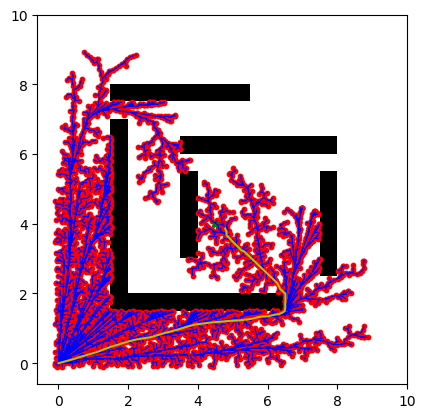

In [117]:
A = Node(0, 0)

tree = RRT(A, grid, num_iterations=10000, goal=(4.5, 4.0))

tree.run_RRT()
plt.imshow(data_np, cmap='gray_r', origin='lower',
           extent=[0, grid.info.width * grid.info.resolution,
                   0, grid.info.height * grid.info.resolution])
tree.plot_tree()
plt.show()



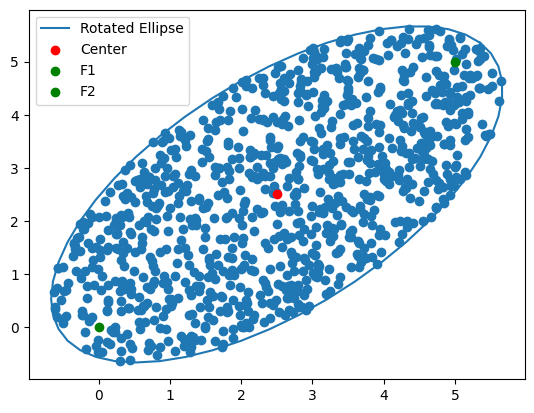

In [114]:
f1x = 0
f1y = 0

f2x = 5
f2y = 5

dx = f2x - f1x
dy = f2y - f1y

xc = (f1x + f2x) / 2
yc = (f1y + f2y) / 2

c_min = math.hypot(dy, dx)

best_cost = c_min + 1.0

a = best_cost / 2.0
b = math.sqrt(best_cost**2 - c_min**2) / 2.0
c = (xc, yc)

theta = math.atan2(dy, dx)

t = np.linspace(0, 2 * np.pi)

xs = []
ys = []
for i in range(1000):

    u = random.random()
    v = random.random()

    r = np.sqrt(u)
    theta1 = v * 2 * np.pi

    x_ball = r * np.cos(theta1)
    y_ball = r * np.sin(theta1)

    x_ellipse = a * x_ball
    y_ellipse = b * y_ball

    x_rot = x_ellipse * np.cos(theta) - y_ellipse * np.sin(theta)
    y_rot = x_ellipse * np.sin(theta) + y_ellipse * np.sin(theta)

    x_translated = x_rot + xc
    y_translated = y_rot + yc

    xs.append(x_translated)
    ys.append(y_translated)


plt.scatter(xs, ys)

x = c[0] + a * np.cos(t) * math.cos(theta) - b * np.sin(t) * math.sin(theta)
y = c[1] + a * np.cos(t) * math.sin(theta) + b * np.sin(t) * math.cos(theta)
plt.plot(x, y, label="Rotated Ellipse")

plt.scatter(c[0], c[1], color="red", label="Center")
plt.scatter(f1x, f1y, color="green", label="F1")
plt.scatter(f2x, f2y, color="green", label="F2")
#plt.xlim(0, 10)
#plt.ylim(0, 10)
plt.legend()
plt.show()


In [115]:
from scipy.ndimage import binary_dilation

apa = np.array(np.zeros((20, 20)))
#print(apa)

apa[5, 5] = 1
apa[15, 15] = 1

#print(apa)

struct= np.ones((3, 3), dtype=bool)

katt = binary_dilation(apa, struct, 3).astype(apa.dtype)
print(katt)

[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1.

In [116]:
import numpy as np
from scipy.ndimage import distance_transform_edt

inflated = np.array(np.zeros((11, 11)))
inflated[5, :] = 100
inflated[:, 10] = 100

inflated = (inflated != 100)

inflated = distance_transform_edt(inflated, sampling=0.03)
print(inflated)


[[0.15 0.15 0.15 0.15 0.15 0.15 0.12 0.09 0.06 0.03 0.  ]
 [0.12 0.12 0.12 0.12 0.12 0.12 0.12 0.09 0.06 0.03 0.  ]
 [0.09 0.09 0.09 0.09 0.09 0.09 0.09 0.09 0.06 0.03 0.  ]
 [0.06 0.06 0.06 0.06 0.06 0.06 0.06 0.06 0.06 0.03 0.  ]
 [0.03 0.03 0.03 0.03 0.03 0.03 0.03 0.03 0.03 0.03 0.  ]
 [0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.03 0.03 0.03 0.03 0.03 0.03 0.03 0.03 0.03 0.03 0.  ]
 [0.06 0.06 0.06 0.06 0.06 0.06 0.06 0.06 0.06 0.03 0.  ]
 [0.09 0.09 0.09 0.09 0.09 0.09 0.09 0.09 0.06 0.03 0.  ]
 [0.12 0.12 0.12 0.12 0.12 0.12 0.12 0.09 0.06 0.03 0.  ]
 [0.15 0.15 0.15 0.15 0.15 0.15 0.12 0.09 0.06 0.03 0.  ]]
